<a href="https://colab.research.google.com/github/Recollectionss/University/blob/main/4-course/sem-2/miod/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       pl_name   hostname  discoverymethod    pl_orbper  pl_rade  pl_bmasse
0  HD 156279 b  HD 156279  Radial Velocity   131.050000      NaN   3086.000
1     GJ 832 b     GJ 832  Radial Velocity  3507.000000      NaN    197.046
2    GJ 1214 b    GJ 1214          Transit     1.580405     2.27      6.430
3   HD 24040 b   HD 24040  Radial Velocity  3668.000000      NaN   1274.440
4  HD 168443 c  HD 168443  Radial Velocity  1749.830000      NaN   5464.221
pl_name                0
hostname               0
discoverymethod        0
pl_orbper           3331
pl_rade            12325
pl_bmasse          32192
dtype: int64


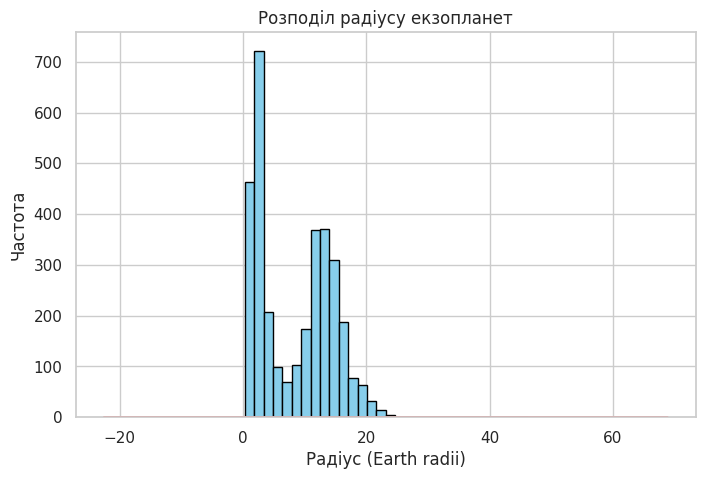

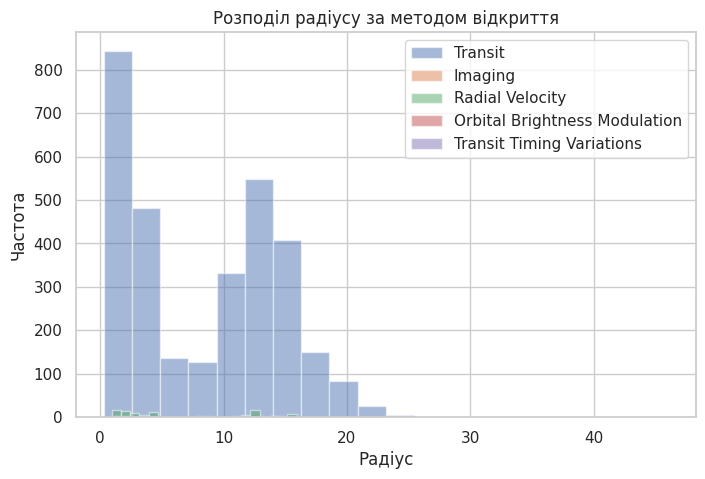

Висновок 2.1: більшість екзопланет мають невеликий радіус, але є великі газові гіганти.


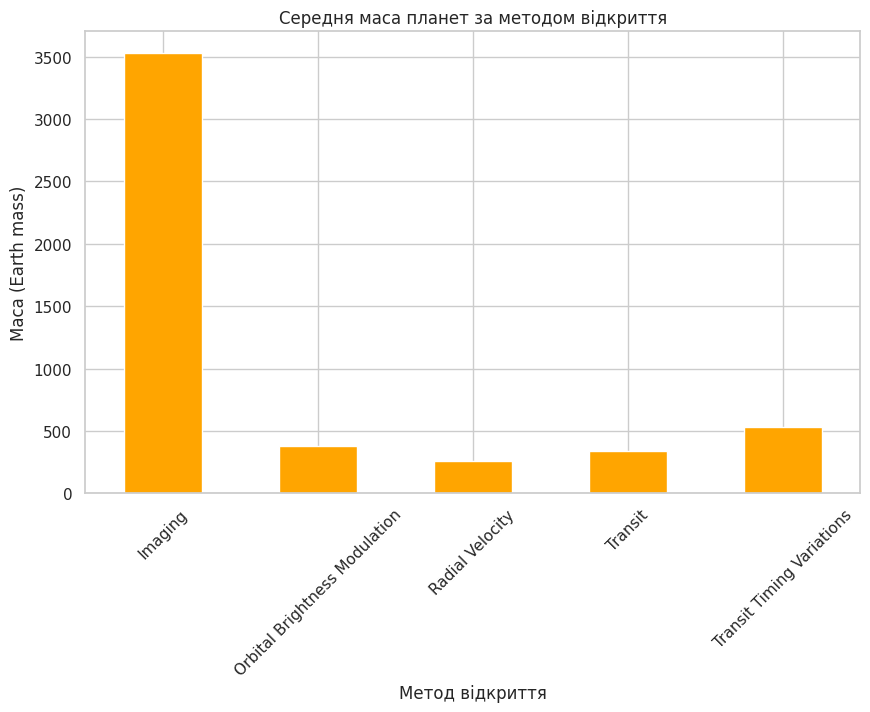

Висновок 2.2: різні методи відкриття виявляють різні типи планет.


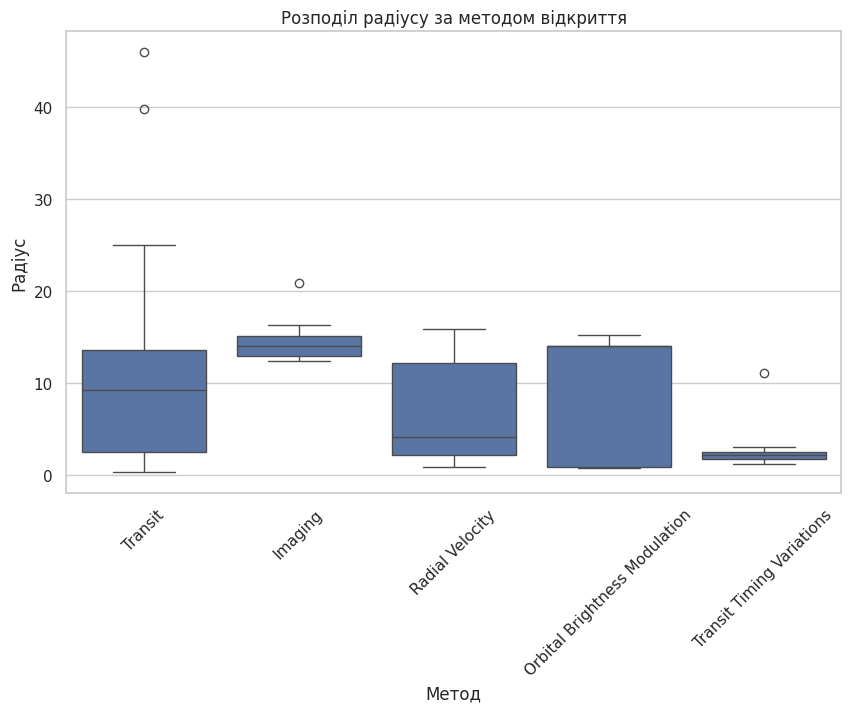

Висновок 2.3: видно медіани та викиди для кожного методу.


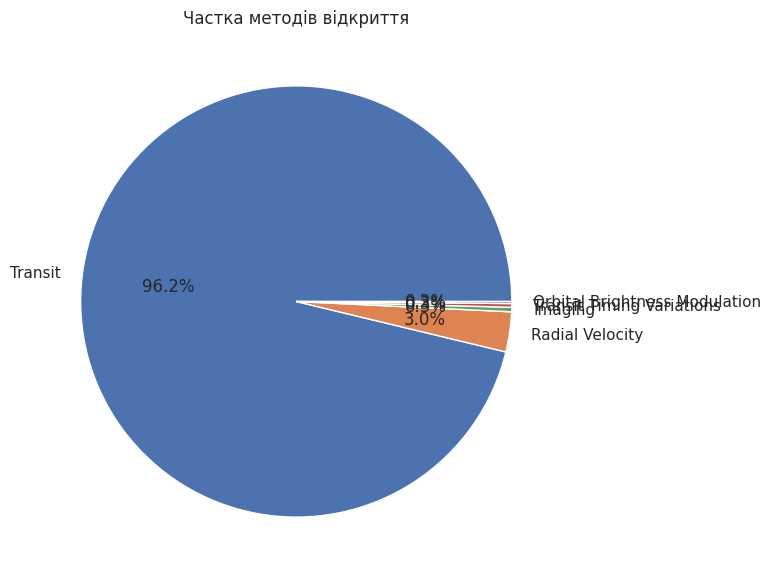

Висновок 2.4: найбільше планет відкрито певним методом (наприклад Transit).


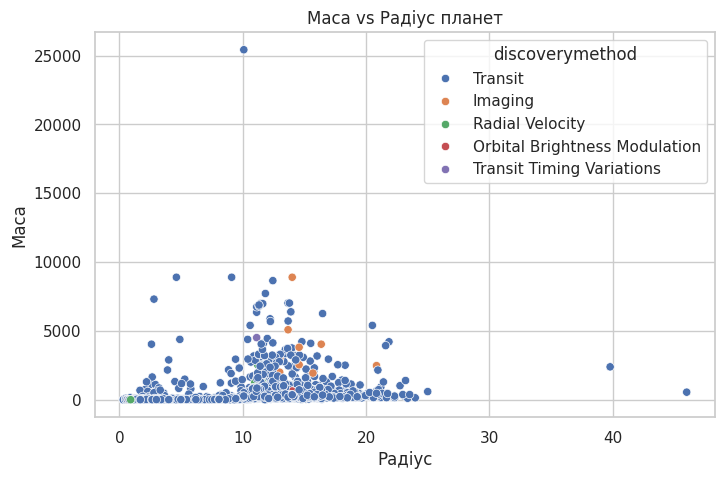

Висновок 2.5: існує залежність між масою та радіусом.


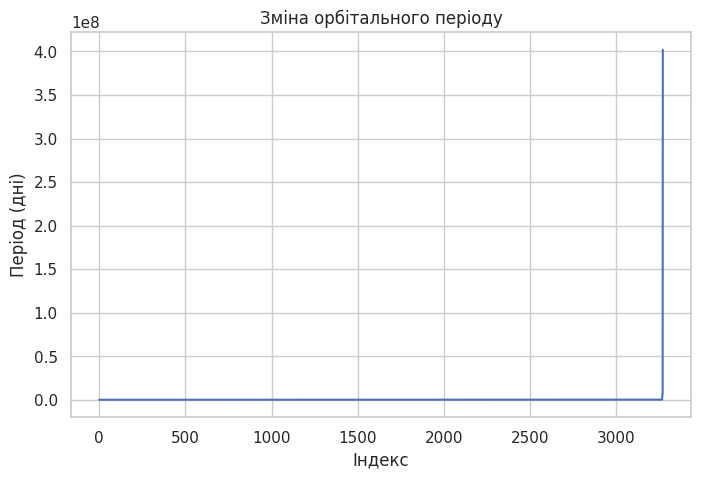

Висновок 2.6: більшість планет мають короткі орбіти.


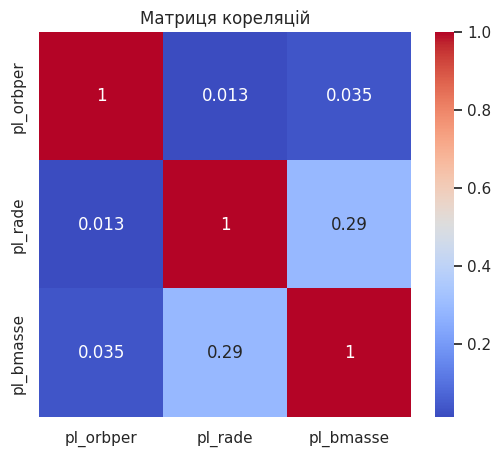

Висновок 2.7: маса і радіус сильно корелюють.


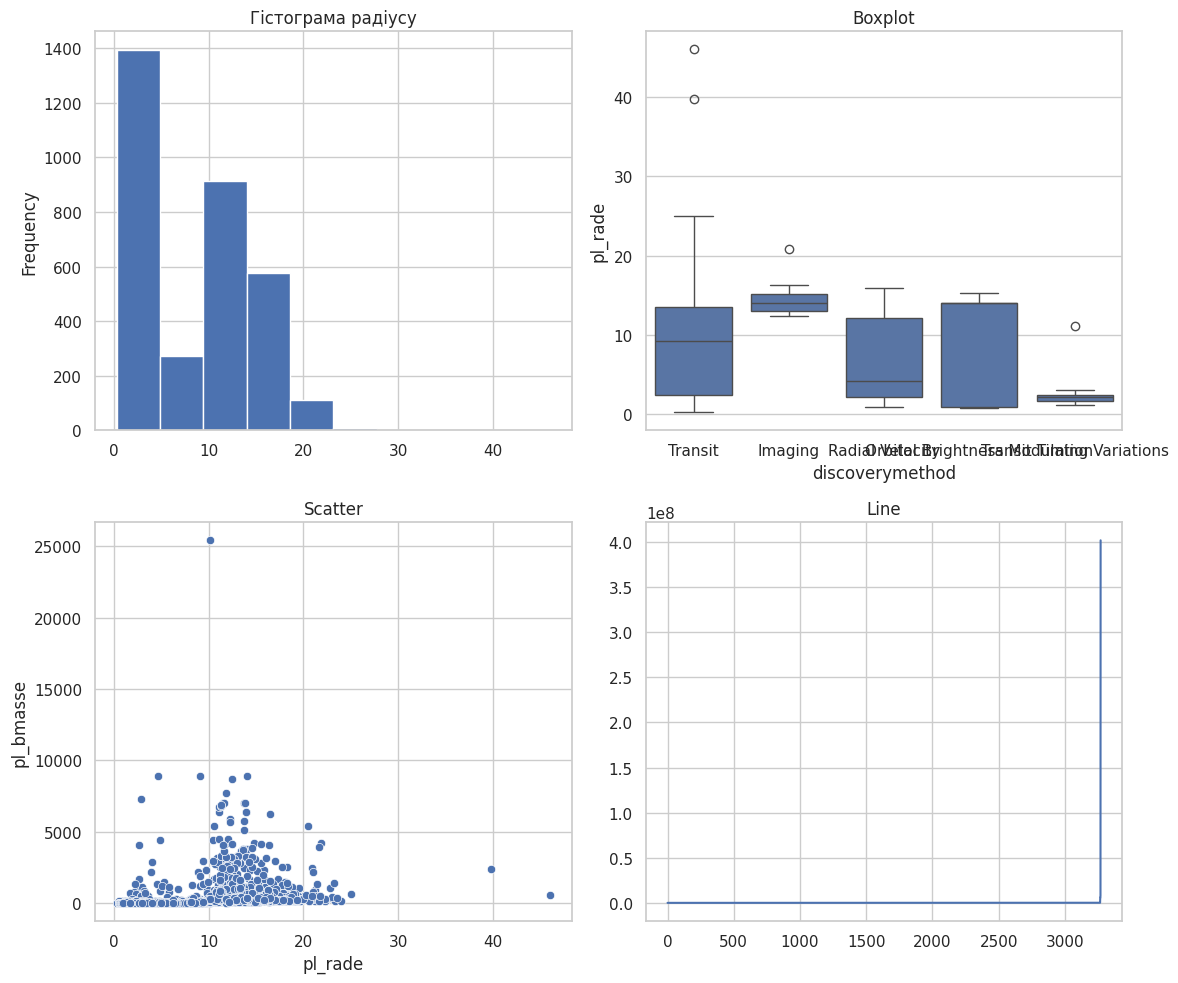

Висновок 2.8: комбінований аналіз дає повну картину характеристик екзопланет.


In [1]:
# =========================
# 1. ІМПОРТИ
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# 1.1 ЗАВАНТАЖЕННЯ ДАНИХ
# =========================
# 1.1
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,hostname,discoverymethod,pl_orbper,pl_rade,pl_bmasse+from+ps&format=csv"

df = pd.read_csv(url)

print(df.head())

# =========================
# 1.2 ПІДГОТОВКА ДАНИХ
# =========================
# 1.2 - перевірка пропусків
print(df.isnull().sum())

# видалення пропусків
df = df.dropna()

# типи
df["pl_orbper"] = pd.to_numeric(df["pl_orbper"], errors='coerce')
df["pl_rade"] = pd.to_numeric(df["pl_rade"], errors='coerce')
df["pl_bmasse"] = pd.to_numeric(df["pl_bmasse"], errors='coerce')

df = df.dropna()

# =========================
# 2.1 РОЗПОДІЛ
# =========================
# 2.1
plt.figure(figsize=(8,5))
df["pl_rade"].plot.hist(bins=30, color="skyblue", edgecolor="black")
df["pl_rade"].plot.kde(color="red")
plt.title("Розподіл радіусу екзопланет")
plt.xlabel("Радіус (Earth radii)")
plt.ylabel("Частота")
plt.show()

# по категоріях
plt.figure(figsize=(8,5))
for method in df["discoverymethod"].unique():
    df[df["discoverymethod"] == method]["pl_rade"].plot.hist(alpha=0.5, bins=20, label=method)

plt.legend()
plt.title("Розподіл радіусу за методом відкриття")
plt.xlabel("Радіус")
plt.ylabel("Частота")
plt.show()

print("Висновок 2.1: більшість екзопланет мають невеликий радіус, але є великі газові гіганти.")

# =========================
# 2.2 BAR
# =========================
# 2.2
grouped = df.groupby(["discoverymethod"])["pl_bmasse"].mean()

grouped.plot(kind="bar", figsize=(10,6), color="orange")
plt.title("Середня маса планет за методом відкриття")
plt.xlabel("Метод відкриття")
plt.ylabel("Маса (Earth mass)")
plt.xticks(rotation=45)
plt.show()

print("Висновок 2.2: різні методи відкриття виявляють різні типи планет.")

# =========================
# 2.3 BOXPLOT
# =========================
# 2.3
plt.figure(figsize=(10,6))
sns.boxplot(x="discoverymethod", y="pl_rade", data=df)
plt.xticks(rotation=45)
plt.title("Розподіл радіусу за методом відкриття")
plt.xlabel("Метод")
plt.ylabel("Радіус")
plt.show()

print("Висновок 2.3: видно медіани та викиди для кожного методу.")

# =========================
# 2.4 PIE
# =========================
# 2.4
pie_data = df["discoverymethod"].value_counts()

plt.figure(figsize=(7,7))
pie_data.plot.pie(autopct='%1.1f%%')
plt.title("Частка методів відкриття")
plt.ylabel("")
plt.show()

print("Висновок 2.4: найбільше планет відкрито певним методом (наприклад Transit).")

# =========================
# 2.5 SCATTER
# =========================
# 2.5
plt.figure(figsize=(8,5))
sns.scatterplot(x="pl_rade", y="pl_bmasse", hue="discoverymethod", data=df)
plt.title("Маса vs Радіус планет")
plt.xlabel("Радіус")
plt.ylabel("Маса")
plt.show()

print("Висновок 2.5: існує залежність між масою та радіусом.")

# =========================
# 2.6 LINE
# =========================
# 2.6
df_sorted = df.sort_values(by="pl_orbper")

plt.figure(figsize=(8,5))
plt.plot(df_sorted["pl_orbper"].values)
plt.title("Зміна орбітального періоду")
plt.xlabel("Індекс")
plt.ylabel("Період (дні)")
plt.show()

print("Висновок 2.6: більшість планет мають короткі орбіти.")

# =========================
# 2.7 CORR
# =========================
# 2.7
corr = df[["pl_orbper", "pl_rade", "pl_bmasse"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Матриця кореляцій")
plt.show()

print("Висновок 2.7: маса і радіус сильно корелюють.")

# =========================
# 2.8 SUBPLOTS
# =========================
# 2.8
fig, axes = plt.subplots(2, 2, figsize=(12,10))

df["pl_rade"].plot.hist(ax=axes[0,0])
axes[0,0].set_title("Гістограма радіусу")

sns.boxplot(x="discoverymethod", y="pl_rade", data=df, ax=axes[0,1])
axes[0,1].set_title("Boxplot")

sns.scatterplot(x="pl_rade", y="pl_bmasse", data=df, ax=axes[1,0])
axes[1,0].set_title("Scatter")

axes[1,1].plot(df_sorted["pl_orbper"].values)
axes[1,1].set_title("Line")

plt.tight_layout()
plt.show()

print("Висновок 2.8: комбінований аналіз дає повну картину характеристик екзопланет.")